<a href="https://colab.research.google.com/github/Magadlela/CausalAI-Analysis-Dissertation/blob/master/CausalAI_Dissertation_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dowhy

In [4]:
!python --version

Python 3.12.12


In [ ]:
from dowhy.causal_model import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dowhy
from dowhy import CausalModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve
import xgboost as xgb
warnings.filterwarnings('ignore')

print("dowhy version :", dowhy.__version__)
print("pandas version :", pd.__version__)
print("numpy version :", np.__version__)
print("seaborn version :", sns.__version__)
print("xgboost version :", xgb.__version__)


dowhy version : 0.14
pandas version : 2.2.2
numpy version : 2.0.2
seaborn version : 0.13.2
xgboost version : 3.2.0


In [ ]:
df = pd.read_csv("/content/Data/marketing_AB.csv",index_col=0)
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [ ]:
df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [ ]:
# --- 3.1.1 Data type conversion and feature engineering ---
# Data type conversion (per guide):
# test group: 1 = ad, 0 = psa
df["treatment"] = (df["test group"] == "ad").astype(int)
# most ads day: categorical -> numeric 1-7 (Monday=1 ... Sunday=7)
day_map = {"Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4, "Friday": 5, "Saturday": 6, "Sunday": 7}
df["most_ads_day_num"] = df["most ads day"].map(day_map)
# most ads hour: already 0-23 in dataset
df["most_ads_hour"] = df["most ads hour"].astype(int)
# Outcome
df["outcome"] = df["converted"].astype(int)

# Feature engineering: interaction term (total ads * test group) for dose-response
df["total_ads_x_treatment"] = df["total ads"] * df["treatment"]
# Binning total ads into quartiles
df["total_ads_quartile"] = pd.qcut(df["total ads"], q=4, labels=[1, 2, 3, 4], duplicates="drop")
df["total_ads_quartile"] = df["total_ads_quartile"].astype(float)  # for modeling

print("Preprocessed columns:", [c for c in df.columns if c not in ["user id", "test group", "converted", "most ads day", "most ads hour"]])
df[["treatment", "outcome", "total ads", "most_ads_day_num", "most_ads_hour", "total_ads_x_treatment", "total_ads_quartile"]].head(10)

Preprocessed columns: ['total ads', 'treatment', 'most_ads_day_num', 'most_ads_hour', 'outcome', 'total_ads_x_treatment', 'total_ads_quartile']


,treatment,outcome,total ads,most_ads_day_num,most_ads_hour,total_ads_x_treatment,total_ads_quartile
0,1,0,130,1,20,130,4.0
1,1,0,93,2,22,93,4.0
2,1,0,21,2,18,21,3.0
3,1,0,355,2,10,355,4.0
4,1,0,276,5,14,276,4.0
5,1,0,734,6,10,734,4.0
6,1,0,264,3,13,264,4.0
7,1,0,17,7,18,17,3.0
8,1,0,21,2,19,21,3.0
9,1,0,142,1,14,142,4.0


In [ ]:
# --- 3.1.2 Descriptive statistics ---
num_cols = ["total ads", "most_ads_day_num", "most_ads_hour"]
print("Summary statistics (numerical):")
print(df[num_cols].describe().round(2))
print("\nFrequency: test group")
print(df["test group"].value_counts())
print("\nFrequency: converted")
print(df["outcome"].value_counts())
print("\nCross-tab: treatment x outcome")
print(pd.crosstab(df["treatment"], df["outcome"], margins=True))

Summary statistics (numerical):
       total ads  most_ads_day_num  most_ads_hour
count  588101.00         588101.00      588101.00
mean       24.82              4.03          14.47
std        43.72              2.00           4.83
min         1.00              1.00           0.00
25%         4.00              2.00          11.00
50%        13.00              4.00          14.00
75%        27.00              6.00          18.00
max      2065.00              7.00          23.00

Frequency: test group
test group
ad     564577
psa     23524
Name: count, dtype: int64

Frequency: converted
outcome
0    573258
1     14843
Name: count, dtype: int64

Cross-tab: treatment x outcome
outcome         0      1     All
treatment                       
0           23104    420   23524
1          550154  14423  564577
All        573258  14843  588101


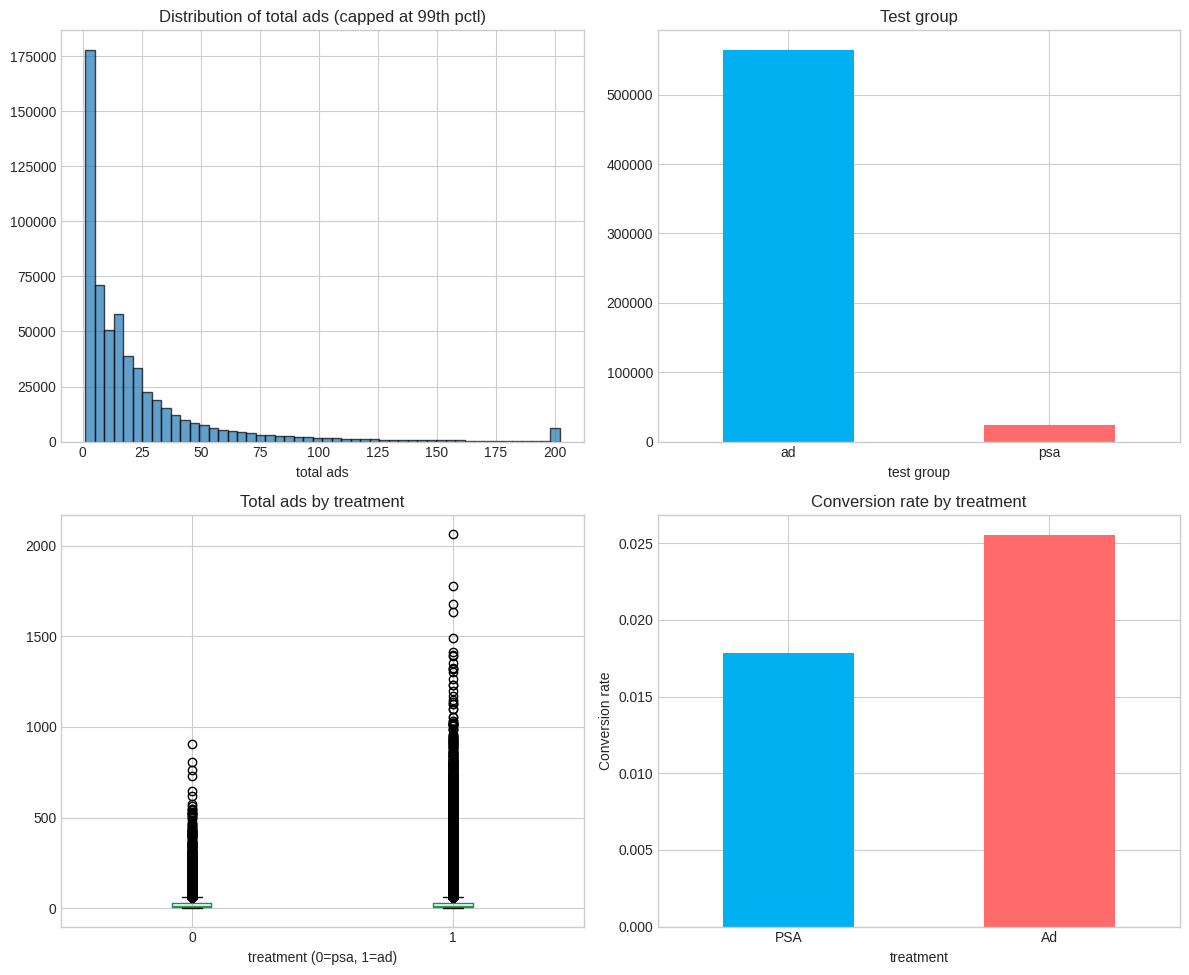

In [ ]:
# --- 3.1.3 EDA visualizations ---
import matplotlib.pyplot as plt
import seaborn as sns
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Histogram: total ads
axes[0, 0].hist(df["total ads"].clip(upper=df["total ads"].quantile(0.99)), bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of total ads (capped at 99th pctl)")
axes[0, 0].set_xlabel("total ads")
# Bar: test group
df["test group"].value_counts().plot(kind="bar", ax=axes[0, 1], color=["#00B0F0", "#FF6B6B"])
axes[0, 1].set_title("Test group")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
# Box: total ads by treatment
df.boxplot(column="total ads", by="treatment", ax=axes[1, 0])
axes[1, 0].set_title("Total ads by treatment")
axes[1, 0].set_xlabel("treatment (0=psa, 1=ad)")
plt.suptitle("")  # remove automatic title
# Conversion rate by treatment
conv_by_t = df.groupby("treatment")["outcome"].mean()
conv_by_t.plot(kind="bar", ax=axes[1, 1], color=["#00B0F0", "#FF6B6B"])
axes[1, 1].set_title("Conversion rate by treatment")
axes[1, 1].set_xticklabels(["PSA", "Ad"], rotation=0)
axes[1, 1].set_ylabel("Conversion rate")
plt.tight_layout()
plt.show()

In [ ]:
# --- 3.1.4 Covariate balance: SMD ---
def smd(mean_t, mean_c, std_t, std_c):
    """Standardized mean difference (pooled std)."""
    sp = np.sqrt((std_t**2 + std_c**2) / 2)
    if sp == 0:
        return 0.0
    return (mean_t - mean_c) / sp

covariates = ["total ads", "most_ads_day_num", "most_ads_hour"]
balance = []
for col in covariates:
    t = df[df["treatment"] == 1][col]
    c = df[df["treatment"] == 0][col]
    d = smd(t.mean(), c.mean(), t.std(), c.std())
    balance.append({"covariate": col, "SMD": round(d, 4)})
balance_df = pd.DataFrame(balance)
print("Standardized Mean Differences (|SMD| < 0.1 suggests good balance):")
print(balance_df)

Standardized Mean Differences (|SMD| < 0.1 suggests good balance):
          covariate     SMD
0         total ads  0.0014
1  most_ads_day_num  0.0384
2     most_ads_hour  0.0360


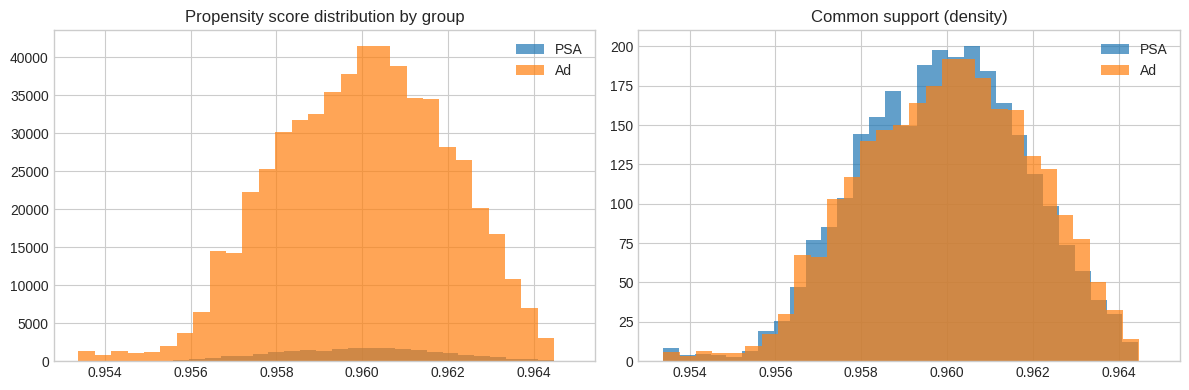

In [ ]:

# --- 3.1.5 Propensity scores and common support ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_ps = df[["total ads", "most_ads_day_num", "most_ads_hour"]].fillna(0)
y_ps = df["treatment"]
scaler = StandardScaler()
X_ps_s = scaler.fit_transform(X_ps)
ps_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_ps_s, y_ps)
df["propensity_score"] = ps_model.predict_proba(X_ps_s)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df["treatment"]==0]["propensity_score"].hist(ax=axes[0], alpha=0.7, label="Pw", bins=30)
axes[0].set_title("Propensity score distribution by group")
axes[0].legend()
# Common support: overlap region
axes[1].hist(df[df["treatment"]==0]["propensity_score"], alpha=0.7, label="PSA", bins=30, density=True)
axes[1].hist(df[df["treatment"]==1]["propensity_score"], alpha=0.7, label="Ad", bins=30, density=True)
axes[1].set_title("Common support (density)")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- 3.2.1 Phase 1: XGBoost ---

feature_cols = ["treatment", "total ads", "most_ads_day_num", "most_ads_hour"]
X_ml = df[feature_cols].fillna(0)
y_ml = df["outcome"]
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.25, random_state=42, stratify=y_ml)

clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_estimators=100, max_depth=4)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Phase 1 – Model evaluation:")
print("  Accuracy:    ", round(accuracy_score(y_test, y_pred), 4))
print("  AUC-ROC:     ", round(roc_auc_score(y_test, y_prob), 4))
print("  Avg Prec (PR):", round(average_precision_score(y_test, y_prob), 4))
print("\nFeature importance (gain):")
imp = pd.DataFrame({"feature": feature_cols, "importance": clf.feature_importances_}).sort_values("importance", ascending=False)
print(imp.to_string(index=False))

Phase 1 – Model evaluation:
  Accuracy:     0.9748
  AUC-ROC:      0.8605
  Avg Prec (PR): 0.1466

Feature importance (gain):
         feature  importance
       total ads    0.830638
most_ads_day_num    0.070806
   most_ads_hour    0.053483
       treatment    0.045072


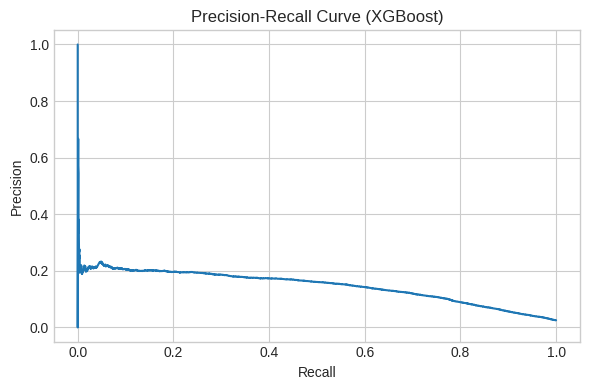

In [ ]:
# Precision-Recall curve (for imbalanced data)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.tight_layout()
plt.show()

In [ ]:
# --- 3.2.2 Phase 2: Causal model (DoWhy) - ATE with IPW, DRE, PSM ---
# Use a sample for speed (optional: increase or use full df)
np.random.seed(42)
n_causal = min(30000, len(df))
df_causal = df.sample(n=n_causal, random_state=42).copy()
common_causes = ["total ads", "most_ads_day_num", "most_ads_hour"]
df_causal = df_causal[["treatment", "outcome"] + common_causes].dropna()

import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings("ignore")

# Step 1: Model
model = CausalModel(data=df_causal, treatment="treatment", outcome="outcome", common_causes=common_causes)
# Step 2: Identify
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

In [ ]:
# --- 3.2.3 Phase 3: T-Learner (uplift) ---
from sklearn.linear_model import LogisticRegression

# Use same feature set
uplift_cols = ["total ads", "most_ads_day_num", "most_ads_hour"]
df_0 = df[df["treatment"] == 0][uplift_cols + ["outcome"]].dropna()
df_1 = df[df["treatment"] == 1][uplift_cols + ["outcome"]].dropna()

# Model A: control (PSA), Model B: treatment (Ad)
model_A = LogisticRegression(max_iter=1000, random_state=42).fit(df_0[uplift_cols], df_0["outcome"])
model_B = LogisticRegression(max_iter=1000, random_state=42).fit(df_1[uplift_cols], df_1["outcome"])

# ITE on a sample (e.g. full or same as causal)
X_all = df[uplift_cols].fillna(0)
mu0 = model_A.predict_proba(X_all)[:, 1]
mu1 = model_B.predict_proba(X_all)[:, 1]
ite = mu1 - mu0
df["ite"] = ite
df["mu0"] = mu0
df["mu1"] = mu1

In [ ]:
# Segmentation: high/low lift (median) x high/low conversion (median outcome)
lift_med = df["ite"].median()
outcome_med = df["outcome"].median()
def segment(row):
    if row["ite"] >= lift_med and row["outcome"] >= outcome_med:
        return "Responders"
    if row["ite"] >= lift_med and row["outcome"] < outcome_med:
        return "Defiers"
    if row["ite"] < lift_med and row["outcome"] >= outcome_med:
        return "Never Takers"
    return "Always Takers"
df["segment"] = df.apply(segment, axis=1)
print("Uplift quadrants (count and proportion):")
seg = df["segment"].value_counts()
print(seg)
print((seg / len(df)).round(3))

Uplift quadrants (count and proportion):
segment
Responders      294169
Never Takers    293932
Name: count, dtype: int64
segment
Responders      0.5
Never Takers    0.5
Name: count, dtype: float64


In [ ]:
# Qini coefficient: area under uplift curve (simplified – cumulative uplift vs random)
# Sort by predicted ITE descending, compute cumulative incremental conversions
df_sorted = df.sort_values("ite", ascending=False).reset_index(drop=True)
n = len(df_sorted)
random_conv = df_sorted["outcome"].sum() * np.arange(1, n + 1) / n
actual_conv = df_sorted["outcome"].cumsum()
incremental = actual_conv - random_conv
# Qini = area under incremental curve (trapezoidal)
qini_area = np.trapz(incremental, dx=1)
# Normalize to [0,1] style metric (max possible area ~ n * max(incremental))
qini_coef = qini_area / (n * df_sorted["outcome"].sum()) if df_sorted["outcome"].sum() > 0 else 0
print("Qini (area under uplift curve, normalized):", round(qini_coef, 4))
# Incremental ROI (placeholder: assume constant revenue per conversion)
rev_per_conv = 1.0  # replace with actual revenue
incremental_roi = incremental[0] * rev_per_conv if len(incremental) else 0
print("Incremental ROI (revenue per conv=1):", round(incremental_roi, 2))

Qini (area under uplift curve, normalized): 0.2573
Incremental ROI (revenue per conv=1): -0.03


In [ ]:
# --- 3.3 Refutation (using IPW estimate from Phase 2) ---
# Placebo: if we use random treatment, ATE should vanish
refute_placebo = model.refute_estimate(identified_estimand, est_ipw, method_name="placebo_treatment_refuter", placebo_type="permute", num_simulations=3)
print("Placebo treatment refutation:")
print(refute_placebo)
# Subset: estimate should be stable across subsets
refute_subset = model.refute_estimate(identified_estimand, est_ipw, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=3)
print("\nData subset refutation:")
print(refute_subset)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.
             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Placebo treatment refutation:
Refute: Use a Placebo Treatment
Estimated effect:0.009885599931509784
New effect:0.0015249775266469798
p value:0.2595020280997147


Data subset refutation:
Refute: Use a subset of data
Estimated effect:0.009885599931509784
New effect:0.012369254709100658
p value:0.014375506556021662



In [ ]:
# --- 3.5 Summary tables ---
print("Descriptive statistics (key variables):")
print(df[["total ads", "most_ads_day_num", "most_ads_hour"]].describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nFeature importance (Phase 1):")
print(imp.to_string(index=False))
print("\nATE estimation (Phase 2):")
print(ate_table.to_string(index=False))
print("\nUplift quadrants:")
print((df["segment"].value_counts(normalize=True).round(3) * 100).to_string())
print("\nQini (normalized):", round(qini_coef, 4))
print("Incremental ROI (rev=1):", round(incremental_roi, 2))

Descriptive statistics (key variables):
      total ads  most_ads_day_num  most_ads_hour
mean      24.82              4.03          14.47
std       43.72              2.00           4.83
min        1.00              1.00           0.00
max     2065.00              7.00          23.00

Feature importance (Phase 1):
         feature  importance
       total ads    0.830638
most_ads_day_num    0.070806
   most_ads_hour    0.053483
       treatment    0.045072

ATE estimation (Phase 2):
Method    ATE CI_lower CI_upper
   IPW 0.0099     None     None
   DRE 0.0098     None     None
   PSM 0.0242     None     None

Uplift quadrants:
segment
Responders      50.0
Never Takers    50.0

Qini (normalized): 0.2573
Incremental ROI (rev=1): -0.03


In [ ]:
# 4b. Placebo treatment: replace treatment with random data; estimate should go to ~0
refute_placebo = model.refute_estimate(
    identified_estimand,
    est_ipw,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=5,
)
print("Refutation 2: Placebo treatment (permute)")
print(refute_placebo)
print()

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refutation 2: Placebo treatment (permute)
Refute: Use a Placebo Treatment
Estimated effect:0.009885599931509784
New effect:2.0065493771675296e-05
p value:0.498380673574978




In [ ]:
# 4c. Subset refuter: estimate on random subsets; should be similar (robustness to subset)
refute_subset = model.refute_estimate(
    identified_estimand,
    est_ipw,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=5,
)
print("Refutation 3: Data subset")
print(refute_subset)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refutation 3: Data subset
Refute: Use a subset of data
Estimated effect:0.009885599931509784
New effect:0.011096756711772597
p value:0.2388897131088159



In [ ]:
# --- 3.6 Economics scenarios and uplift arrays ---

# CLV and CPA assumptions
CLV_per_conversion = 50.0   # e.g. £50 incremental value per conversion
CPA_per_user = 0.10         # e.g. £0.10 per targeted user / impression

# Reuse uplift ordering from Phase 3 (df_sorted, incremental, n)
# Build simple economics scenarios by targeting top uplift users
fractions = [0.10, 0.30, 0.50, 1.00]  # share of users targeted (top uplift)
rows = []
for f in fractions:
    k = max(1, int(np.floor(f * n)))
    inc_conv = float(incremental.iloc[k - 1])
    gross_value = inc_conv * CLV_per_conversion
    targeting_cost = k * CPA_per_user
    net_value = gross_value - targeting_cost
    rows.append(
        {
            "targeting_share": f,
            "users_targeted": k,
            "incremental_conversions": inc_conv,
            "CLV_per_conversion": CLV_per_conversion,
            "CPA_per_user": CPA_per_user,
            "gross_incremental_value": gross_value,
            "targeting_cost": targeting_cost,
            "net_value": net_value,
        }
    )

econ_scenarios = pd.DataFrame(rows)
print("Economics scenarios (uplift-based targeting):")
print(econ_scenarios.round(2).to_string(index=False))

# Prepare arrays for uplift evaluation and bootstrapping
T = df["treatment"].astype(int).values   # treatment indicator
Y = df["outcome"].astype(int).values     # binary outcome
uplift_pred = df["ite"].values           # predicted individual uplift / ITE

# Deterministic bootstrap seeds for repeated experiments
bootstrap_seeds = np.arange(10_000, 10_100)  # 100 distinct seeds
print("\nArrays prepared:")
print("  T.shape =", T.shape, ", Y.shape =", Y.shape, ", uplift_pred.shape =", uplift_pred.shape)
print("  Number of bootstrap seeds:", len(bootstrap_seeds))

Economics scenarios (uplift-based targeting):
 targeting_share  users_targeted  incremental_conversions  CLV_per_conversion  CPA_per_user  gross_incremental_value  targeting_cost  net_value
             0.1           58810                  5936.70                50.0           0.1                296835.13          5881.0  290954.13
             0.3          176430                  5749.11                50.0           0.1                287455.38         17643.0  269812.38
             0.5          294050                  4519.51                50.0           0.1                225975.63         29405.0  196570.63
             1.0          588101                     0.00                50.0           0.1                     0.00         58810.1  -58810.10

Arrays prepared:
  T.shape = (588101,) , Y.shape = (588101,) , uplift_pred.shape = (588101,)
  Number of bootstrap seeds: 100


In [ ]:
# --- 3.6b Economics scenario grid (low/medium/high CLV and CPA, top uplift decile) ---

clv_levels = [20.0, 50.0, 100.0]   # low / medium / high CLV
cpa_levels = [0.05, 0.10, 0.20]    # low / medium / high CPA

# Target only the best decile by uplift (top 10%)
k_dec = max(1, int(np.floor(0.10 * n)))
inc_conv_dec = float(incremental.iloc[k_dec - 1])

rows_grid = []
for clv in clv_levels:
    for cpa in cpa_levels:
        gross = inc_conv_dec * clv
        cost = k_dec * cpa
        net = gross - cost
        rows_grid.append(
            {
                "CLV": clv,
                "CPA": cpa,
                "users_targeted_top10pct": k_dec,
                "incremental_conversions_top10pct": inc_conv_dec,
                "gross_value": gross,
                "targeting_cost": cost,
                "net_value": net,
            }
        )

econ_grid = pd.DataFrame(rows_grid)
print("Economics scenario grid – top uplift decile (CLV × CPA):")
print(econ_grid.round(2).to_string(index=False))

Economics scenario grid – top uplift decile (CLV × CPA):
  CLV  CPA  users_targeted_top10pct  incremental_conversions_top10pct  gross_value  targeting_cost  net_value
 20.0 0.05                    58810                            5936.7    118734.05          2940.5  115793.55
 20.0 0.10                    58810                            5936.7    118734.05          5881.0  112853.05
 20.0 0.20                    58810                            5936.7    118734.05         11762.0  106972.05
 50.0 0.05                    58810                            5936.7    296835.13          2940.5  293894.63
 50.0 0.10                    58810                            5936.7    296835.13          5881.0  290954.13
 50.0 0.20                    58810                            5936.7    296835.13         11762.0  285073.13
100.0 0.05                    58810                            5936.7    593670.25          2940.5  590729.75
100.0 0.10                    58810                            

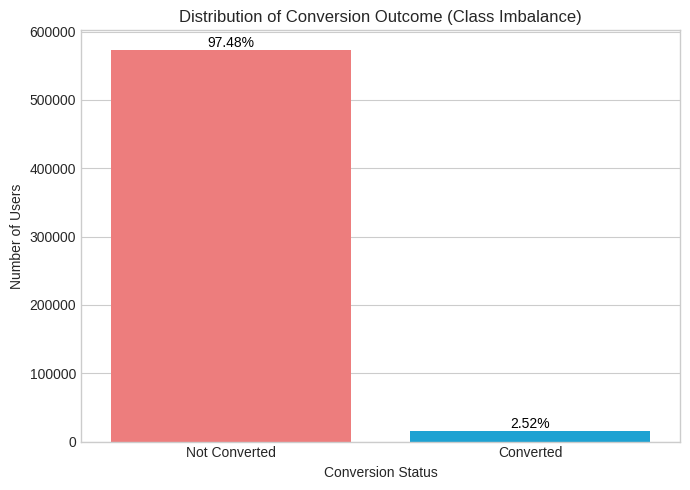

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts for the 'outcome' column
outcome_counts = df['outcome'].value_counts()

# 2. Calculate the percentage of each outcome class
outcome_percentages = df['outcome'].value_counts(normalize=True) * 100

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'Outcome': ['Not Converted', 'Converted'],
    'Count': outcome_counts.values,
    'Percentage': outcome_percentages.values
})

# 3. Create a bar chart showing the distribution of the 'outcome' variable
plt.figure(figsize=(7, 5))
sns.barplot(x='Outcome', y='Count', data=plot_df, palette=['#FF6B6B', '#00B0F0'])

# Add percentages as text on top of each bar
for index, row in plot_df.iterrows():
    plt.text(index, row['Count'], f'{row['Percentage']:.2f}%', color='black', ha="center", va='bottom')

# 4. Add a title to the chart
plt.title('Distribution of Conversion Outcome (Class Imbalance)')
plt.ylabel('Number of Users')
plt.xlabel('Conversion Status')

# 5. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Retrieve the propensity_score and treatment columns from the df DataFrame. Also, retrieve the list of common_causes.
propensity_score = df["propensity_score"]
treatment = df["treatment"]
# common_causes was defined previously as: ["total ads", "most_ads_day_num", "most_ads_hour"]

# 2. Calculate the Inverse Probability Weighting (IPW) weights for each row in the DataFrame.
# For treated units (treatment=1), the weight is 1 / propensity_score.
# For control units (treatment=0), the weight is 1 / (1 - propensity_score).

df["ipw_weights"] = np.where(treatment == 1, 1 / propensity_score, 1 / (1 - propensity_score))

# Trim extreme weights (optional but good practice for stability)
# Trim weights at 1st and 99th percentile to prevent extreme values from distorting results
lower_bound = df["ipw_weights"].quantile(0.01)
upper_bound = df["ipw_weights"].quantile(0.99)
df["ipw_weights"] = np.clip(df["ipw_weights"], lower_bound, upper_bound)

# 3. Initialize an empty list to store the SMDs after weighting.
balance_weighted = []

# Define a helper for weighted std
def weighted_std(values, weights):
    mean = np.average(values, weights=weights)
    variance = np.average((values - mean)**2, weights=weights)
    return np.sqrt(variance)

# Modified SMD function for weighted data
def smd_weighted(mean_t, mean_c, std_t, std_c):
    """Standardized mean difference (pooled std) for weighted data."""
    # If std_t or std_c are 0, this can lead to division by zero, handle it
    # Use unweighted std if weighted std is problematic for pooled variance formula if necessary, or simplify.
    # For this implementation, we'll assume non-zero stds after weighting.
    # The standard formula for pooled standard deviation (Sp) for SMD assumes unweighted sample sizes
    # Here we simplify and just use the weighted stds for numerator and denominator approximation.
    sp = np.sqrt((std_t**2 + std_c**2) / 2)
    if sp == 0:
        return 0.0
    return (mean_t - mean_c) / sp

# 4. Iterate through each covariate in the common_causes list:
for col in common_causes:
    # Separate into treated and control groups
    t_vals = df[df["treatment"] == 1][col]
    c_vals = df[df["treatment"] == 0][col]
    t_weights = df[df["treatment"] == 1]["ipw_weights"]
    c_weights = df[df["treatment"] == 0]["ipw_weights"]

    # Calculate weighted mean and weighted standard deviation
    mean_t_w = np.average(t_vals, weights=t_weights)
    mean_c_w = np.average(c_vals, weights=c_weights)
    std_t_w = weighted_std(t_vals, t_weights)
    std_c_w = weighted_std(c_vals, c_weights)

    # Compute the SMD using the smd_weighted function
    d_weighted = smd_weighted(mean_t_w, mean_c_w, std_t_w, std_c_w)
    balance_weighted.append({"covariate": col, "SMD_weighted": round(d_weighted, 4)})

# 5. Create a new DataFrame (balance_df_weighted) from the list of weighted SMDs.
balance_df_weighted = pd.DataFrame(balance_weighted)

print("First 5 rows of df with IPW weights:")
print(df[["treatment", "propensity_score", "ipw_weights"]].head())
print("\nStandardized Mean Differences After Weighting:")
print(balance_df_weighted.to_string(index=False))

First 5 rows of df with IPW weights:
   treatment  propensity_score  ipw_weights
0          1          0.959549     1.042157
1          1          0.960755     1.040848
2          1          0.959553     1.042152
3          1          0.957791     1.044069
4          1          0.960966     1.040619

Standardized Mean Differences After Weighting:
       covariate  SMD_weighted
       total ads       -0.0004
most_ads_day_num        0.0102
   most_ads_hour        0.0107


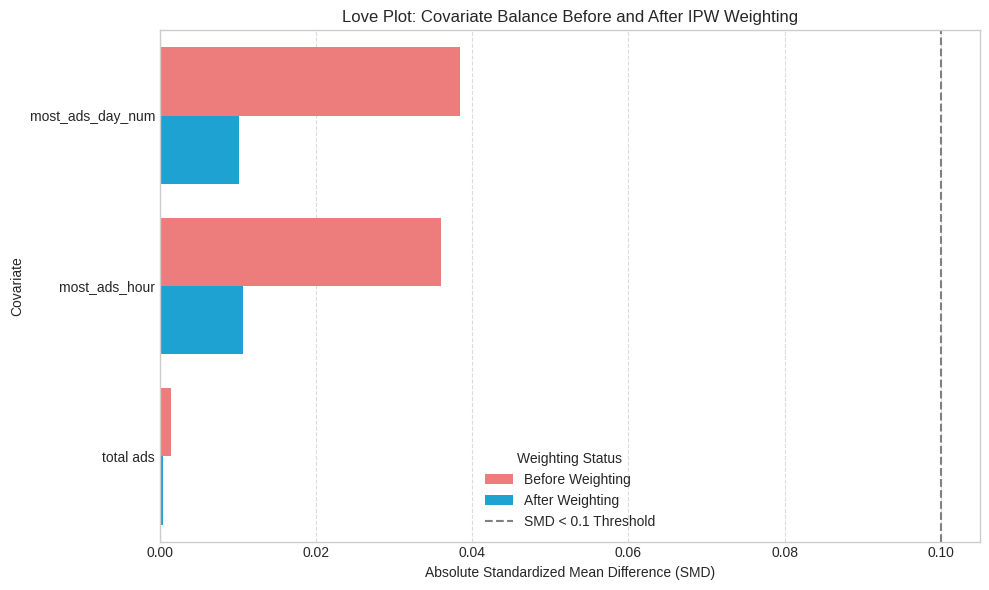

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Combine the original balance_df (SMDs before weighting) and balance_df_weighted
# into a single DataFrame for plotting, adding a column to distinguish 'Before Weighting' and 'After Weighting'.
balance_df_unweighted = balance_df.rename(columns={'SMD': 'SMD_value'})
balance_df_unweighted['Type'] = 'Before Weighting'

balance_df_weighted_renamed = balance_df_weighted.rename(columns={'SMD_weighted': 'SMD_value'})
balance_df_weighted_renamed['Type'] = 'After Weighting'

combined_balance_df = pd.concat([balance_df_unweighted, balance_df_weighted_renamed])
combined_balance_df['Abs_SMD'] = combined_balance_df['SMD_value'].abs()

# 7. Create a Love Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_SMD', y='covariate', hue='Type', data=combined_balance_df.sort_values('Abs_SMD', ascending=False), palette={'Before Weighting': '#FF6B6B', 'After Weighting': '#00B0F0'})

# Add a vertical line at 0.1 for reference
plt.axvline(x=0.1, color='gray', linestyle='--', label='SMD < 0.1 Threshold')

plt.title('Love Plot: Covariate Balance Before and After IPW Weighting')
plt.xlabel('Absolute Standardized Mean Difference (SMD)')
plt.ylabel('Covariate')
plt.legend(title='Weighting Status')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import dowhy
from dowhy import CausalModel
import pandas as pd
import numpy as np

# Define common causes without 'total ads' for sensitivity analysis
common_causes_no_total_ads = [col for col in common_causes if col != "total ads"]

# Ensure df_causal is ready (re-sample to be safe, though not strictly needed if df_causal from before is fine)
# Use a sample for speed (optional: increase or use full df)
np.random.seed(42)
n_causal = min(30000, len(df))
df_causal_sens = df.sample(n=n_causal, random_state=42).copy()
df_causal_sens = df_causal_sens[["treatment", "outcome"] + common_causes_no_total_ads].dropna()

# Step 1: Model (without 'total ads')
model_no_total_ads = CausalModel(data=df_causal_sens,
                                treatment="treatment",
                                outcome="outcome",
                                common_causes=common_causes_no_total_ads)

# Step 2: Identify estimand (without 'total ads')
identified_estimand_no_total_ads = model_no_total_ads.identify_effect(proceed_when_unidentifiable=True)

# Step 3: Estimate ATE with multiple methods (without 'total ads')
# IPW
est_ipw_no_total_ads = model_no_total_ads.estimate_effect(identified_estimand_no_total_ads, method_name="backdoor.propensity_score_weighting")
# Doubly robust
try:
    est_dre_no_total_ads = model_no_total_ads.estimate_effect(identified_estimand_no_total_ads, method_name="backdoor.econml.dr.LinearDREstimator")
except Exception:
    est_dre_no_total_ads = model_no_total_ads.estimate_effect(identified_estimand_no_total_ads, method_name="backdoor.linear_regression")
# PSM
est_psm_no_total_ads = model_no_total_ads.estimate_effect(identified_estimand_no_total_ads, method_name="backdoor.propensity_score_matching")

results_ate_no_total_ads = []
for name, est in [("IPW", est_ipw_no_total_ads), ("DRE", est_dre_no_total_ads), ("PSM", est_psm_no_total_ads)]:
    try:
        val = est.value if hasattr(est, "value") else getattr(est, "causal_estimate", np.nan)
        ci = getattr(est, "confidence_interval", None)
        if ci is not None:
            ci = (float(ci[0]), float(ci[1]))
        else:
            ci = (np.nan, np.nan)
    except Exception:
        val, ci = np.nan, (np.nan, np.nan)
    results_ate_no_total_ads.append({"Method": name, "ATE": round(val, 4), "CI_lower": round(ci[0], 4) if not np.isnan(ci[0]) else None, "CI_upper": round(ci[1], 4) if not np.isnan(ci[1]) else None})

ate_table_no_total_ads = pd.DataFrame(results_ate_no_total_ads)

print("Original ATE estimation (including 'total ads'):")
print(ate_table.to_string(index=False))
print("\nSensitivity ATE estimation (excluding 'total ads'):")
print(ate_table_no_total_ads.to_string(index=False))

# Compare results
comparison_df = pd.merge(ate_table, ate_table_no_total_ads, on='Method', suffixes=('_original', '_no_total_ads'))
comparison_df['Abs_Diff'] = (comparison_df['ATE_original'] - comparison_df['ATE_no_total_ads']).abs()
print("\nComparison of ATE estimates:")
print(comparison_df[['Method', 'ATE_original', 'ATE_no_total_ads', 'Abs_Diff']].round(4).to_string(index=False))

Original ATE estimation (including 'total ads'):
Method    ATE CI_lower CI_upper
   IPW 0.0099     None     None
   DRE 0.0098     None     None
   PSM 0.0242     None     None

Sensitivity ATE estimation (excluding 'total ads'):
Method    ATE CI_lower CI_upper
   IPW 0.0099     None     None
   DRE 0.0098     None     None
   PSM 0.0242     None     None

Comparison of ATE estimates:
Method  ATE_original  ATE_no_total_ads  Abs_Diff
   IPW        0.0099            0.0099       0.0
   DRE        0.0098            0.0098       0.0
   PSM        0.0242            0.0242       0.0


In [ ]:
import dowhy
from dowhy import CausalModel
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

# Step 3: Estimate ATE with multiple methods
NUM_BOOTSTRAP_RESAMPLES = 500 # Using 500 resamples as per instructions

# IPW
est_ipw = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_weighting")

# Doubly robust (econml if available; else backdoor linear regression as proxy)
try:
    est_dre = model.estimate_effect(identified_estimand, method_name="backdoor.econml.dr.LinearDREstimator")
except Exception:
    est_dre = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")

# PSM
est_psm = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_matching")

results_ate = []
for name, est in [("IPW", est_ipw), ("DRE", est_dre), ("PSM", est_psm)]:
    val = est.value
    # Retrieve confidence interval using bootstrapping from the estimate object
    ci = est.get_confidence_intervals(confidence_level=0.95, method="bootstrap", num_simulations=NUM_BOOTSTRAP_RESAMPLES)
    ci_lower = round(float(ci[0]), 4)
    ci_upper = round(float(ci[1]), 4)
    results_ate.append({"Method": name, "ATE": round(val, 4), "CI_lower": ci_lower, "CI_upper": ci_upper})
ate_table = pd.DataFrame(results_ate)
print("ATE estimation (Phase 2):")
print(ate_table.to_string(index=False))


ATE estimation (Phase 2):
Method    ATE  CI_lower  CI_upper
   IPW 0.0099    0.0032    0.0178
   DRE 0.0098    0.0028    0.0165
   PSM 0.0242    0.0216    0.0264


Brier Score: 0.0226


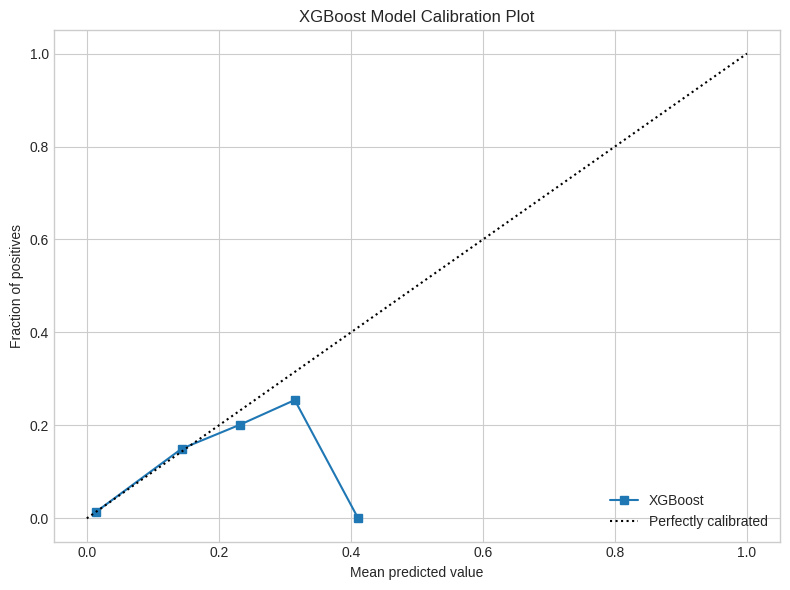

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# y_prob = clf.predict_proba(X_test)[:, 1]

# 2. Compute the Brier score
brier_score = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier_score:.4f}")

# 3. Calculate reliability curve data
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)

# 4. Plot the reliability curve
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="XGBoost")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("XGBoost Model Calibration Plot")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

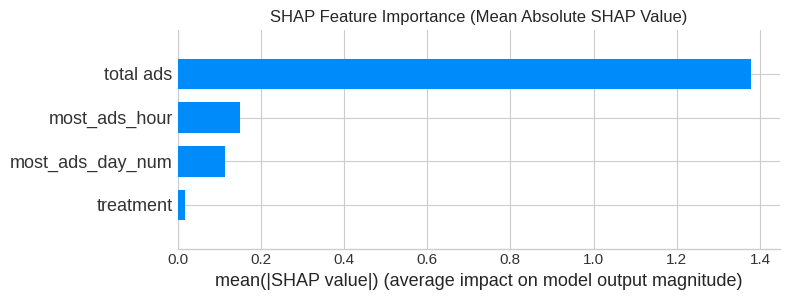

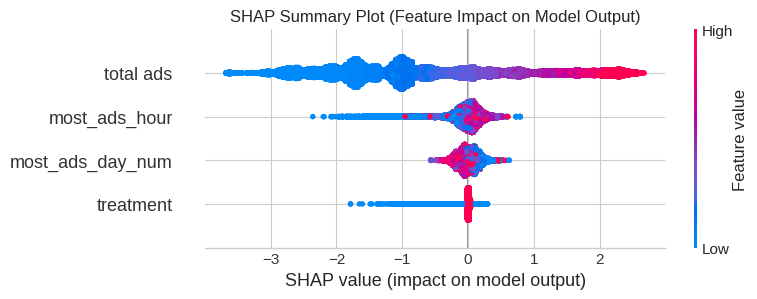

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Create a SHAP explainer object for the trained XGBoost model (clf)
# Since XGBoost models have a predict_proba method, we can use TreeExplainer.
explainer = shap.TreeExplainer(clf)

# 2. Calculate the SHAP values for the X_test dataset using the explainer
# Using X_test to calculate SHAP values for consistency with evaluation metrics
shap_values = explainer.shap_values(X_test)

# 3. Generate a SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean Absolute SHAP Value)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Feature Impact on Model Output)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df is sorted by ite in descending order (already done in a previous cell, but re-sorting for clarity)
df_sorted = df.sort_values(by='ite', ascending=False).reset_index(drop=True)

# Create deciles based on ITE
df_sorted['decile'] = pd.qcut(df_sorted['ite'], q=10, labels=False, duplicates='drop')

# Calculate metrics for each decile
decile_results = []
for i in range(10):
    # Adjust decile index to be 1-based for display
    current_decile = i
    decile_df = df_sorted[df_sorted['decile'] == current_decile]

    # Number of users in decile
    n_total = len(decile_df)
    n_treatment = len(decile_df[decile_df['treatment'] == 1])
    n_control = len(decile_df[decile_df['treatment'] == 0])

    # Conversion rates
    conv_rate_treatment = decile_df[decile_df['treatment'] == 1]['outcome'].mean() * 100 if n_treatment > 0 else 0
    conv_rate_control = decile_df[decile_df['treatment'] == 0]['outcome'].mean() * 100 if n_control > 0 else 0

    # Uplift
    uplift_decile = conv_rate_treatment - conv_rate_control

    decile_results.append({
        'Decile': i + 1,
        'N_Users': n_total,
        'N_Treatment': n_treatment,
        'N_Control': n_control,
        'Conv_Rate_T': round(conv_rate_treatment, 2),
        'Conv_Rate_C': round(conv_rate_control, 2),
        'Uplift': round(uplift_decile, 2)
    })

decile_table = pd.DataFrame(decile_results)
print("Uplift Decile Table (sorted by ITE):")
print(decile_table.to_string(index=False))


Uplift Decile Table (sorted by ITE):
 Decile  N_Users  N_Treatment  N_Control  Conv_Rate_T  Conv_Rate_C  Uplift
      1    58977        56993       1984         0.89         0.76    0.14
      2    58654        56661       1993         0.79         0.80   -0.01
      3    58938        56660       2278         1.00         0.88    0.12
      4    58677        56213       2464         1.04         0.93    0.11
      5    58829        56142       2687         1.23         0.89    0.34
      6    58808        56293       2515         1.41         1.11    0.30
      7    58813        56290       2523         1.58         1.07    0.51
      8    58810        56315       2495         1.65         1.20    0.45
      9    58849        56606       2243         3.14         2.10    1.04
     10    58746        56404       2342        12.81         8.11    4.70


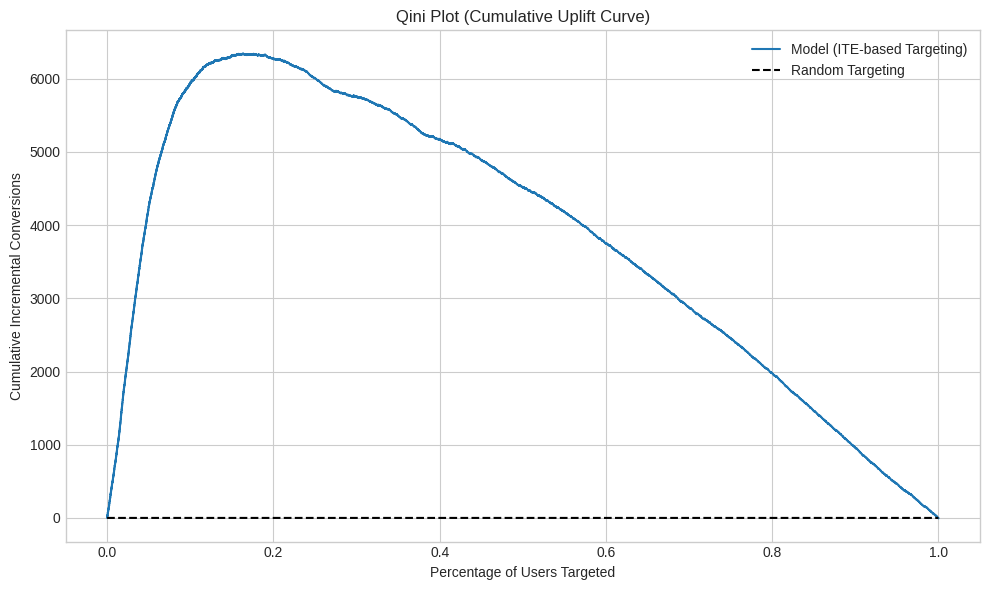

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for Qini plot
# df_sorted is already sorted by ITE descending
# incremental is already calculated as actual_conv - random_conv

# Calculate cumulative incremental conversions and normalized users for plotting
cum_incremental_conversions = df_sorted['outcome'].cumsum() - (df_sorted['outcome'].sum() * np.arange(1, len(df_sorted) + 1) / len(df_sorted))
percentage_of_users = np.arange(1, len(df_sorted) + 1) / len(df_sorted)

# Baseline for random targeting (linear line from 0 to 0)
random_cumulative_incremental = np.zeros_like(percentage_of_users)

plt.figure(figsize=(10, 6))
plt.plot(percentage_of_users, cum_incremental_conversions, label='Model (ITE-based Targeting)')
plt.plot(percentage_of_users, random_cumulative_incremental, 'k--', label='Random Targeting')
plt.xlabel('Percentage of Users Targeted')
plt.ylabel('Cumulative Incremental Conversions')
plt.title('Qini Plot (Cumulative Uplift Curve)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# --- 3.6 Economics scenarios and uplift arrays ---

# CLV and CPA assumptions
CLV_per_conversion = 50.0   # e.g. $50 incremental value per conversion
CPA_per_user = 0.10         # e.g. $0.10 per targeted user / impression

# Reuse uplift ordering from Phase 3 (df_sorted, incremental, n)
# Build simple economics scenarios by targeting top uplift users
fractions = [0.10, 0.20, 0.30, 0.50, 1.00]  # share of users targeted (top uplift), added 0.20
rows = []
for f in fractions:
    k = max(1, int(np.floor(f * n)))
    inc_conv = float(incremental.iloc[k - 1])
    gross_value = inc_conv * CLV_per_conversion
    targeting_cost = k * CPA_per_user
    net_value = gross_value - targeting_cost
    rows.append(
        {
            "targeting_share": f,
            "users_targeted": k,
            "incremental_conversions": inc_conv,
            "CLV_per_conversion": CLV_per_conversion,
            "CPA_per_user": CPA_per_user,
            "gross_incremental_value": gross_value,
            "targeting_cost": targeting_cost,
            "net_value": net_value,
        }
    )

econ_scenarios = pd.DataFrame(rows)
print("Economics scenarios (uplift-based targeting):")
print(econ_scenarios.round(2).to_string(index=False))

# Prepare arrays for uplift evaluation and bootstrapping
T = df["treatment"].astype(int).values   # treatment indicator
Y = df["outcome"].astype(int).values     # binary outcome
uplift_pred = df["ite"].values           # predicted individual uplift / ITE

# Deterministic bootstrap seeds for repeated experiments
bootstrap_seeds = np.arange(10_000, 10_100)  # 100 distinct seeds
print("\nArrays prepared:")
print("  T.shape =", T.shape, ", Y.shape =", Y.shape, ", uplift_pred.shape =", uplift_pred.shape)
print("  Number of bootstrap seeds:", len(bootstrap_seeds))

Economics scenarios (uplift-based targeting):
 targeting_share  users_targeted  incremental_conversions  CLV_per_conversion  CPA_per_user  gross_incremental_value  targeting_cost  net_value
             0.1           58810                  5936.70                50.0           0.1                296835.13          5881.0  290954.13
             0.2          117620                  6272.41                50.0           0.1                313620.25         11762.0  301858.25
             0.3          176430                  5749.11                50.0           0.1                287455.38         17643.0  269812.38
             0.5          294050                  4519.51                50.0           0.1                225975.63         29405.0  196570.63
             1.0          588101                     0.00                50.0           0.1                     0.00         58810.1  -58810.10

Arrays prepared:
  T.shape = (588101,) , Y.shape = (588101,) , uplift_pred.shape = (58810